<a href="https://colab.research.google.com/github/JamesTan44181/DLI-Group-Assignment/blob/main/GroupAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup


In [17]:
import numpy as np
import pandas as pd
import time
import gdown
import glob
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import os
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from sklearn.utils import class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
import warnings

np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

The dataset is download from UNB but colab cannot directly access to the link. Hence, we upload into a public google drive to download by using the url. (IDS 2017 | Datasets | Research | Canadian Institute for Cybersecurity | UNB, n.d.)

In [3]:
# target file
data_dir = "CIC_IDS2017"
if not os.path.exists(data_dir):
    # Download zip file of dataset for whole dataset
    file_id = "1pMMlyzmJNvURynMO0_WztdIhl6oFPASo"
    url = f"https://drive.google.com/uc?id={file_id}"
    output = "CIC-IDS2017.zip"

    # Download for only Monday-WorkingHours.csv
    #file_id = "1p9vawaAKIMof7zZY2QP-AIZEYN0k9c1u"
    #url = f"https://drive.google.com/uc?id={file_id}"
    #output = "CICIDS2017.zip"
    gdown.download(url, output, quiet=False)

    # extract
    !unzip -q CIC-IDS2017.zip -d CIC_IDS2017
else:
    print("Dataset already exists, skip downloading.")

files = glob.glob("CIC_IDS2017/MachineLearningCVE/*.csv")

sampled_dfs = []

for file in files:
    print("Processing:", file)
    df = pd.read_csv(file)

    # get 40,000 in each csv
    df_sample = df.sample(n=min(40000, len(df)), random_state=42)

    sampled_dfs.append(df_sample)

# combine the data we need to used
df_combined = pd.concat(sampled_dfs, ignore_index=True)

print("Total rows after sampling:", len(df_combined))

# save
df_combined.to_csv("CICIDS2017_sampled.csv", index=False)
print("Saved to CICIDS2017_sampled.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1pMMlyzmJNvURynMO0_WztdIhl6oFPASo
From (redirected): https://drive.google.com/uc?id=1pMMlyzmJNvURynMO0_WztdIhl6oFPASo&confirm=t&uuid=7fa94bdf-1302-4a14-b2fa-0dafc369bf12
To: /content/CIC-IDS2017.zip
100%|██████████| 235M/235M [00:03<00:00, 74.8MB/s]


Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
Processing: CIC_IDS2017/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
Total rows after sampling: 320000
Saved to CICIDS2017_sampled.csv


In [4]:
# To combine all CSV and show the first five rows
#csv_files = glob.glob('CIC_IDS2017/MachineLearningCVE/Monday-WorkingHours.csv')
#df_list = [pd.read_csv(f) for f in csv_files]
#df = pd.concat(df_list, ignore_index=True)
#df.head()
# To get only Monday-WorkingHours dataset on CIC-IDS2017 dataset
df_combined.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,77689,4,8,6134,153,4686,0,1533.5,2209.736862,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,443,3659078,10,9,717,5821,363,0,71.7,121.708258,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,44176,76,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
3,8641,81,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,1026,61,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan


# Pre-processing

Data Cleaning

In [5]:
# Show the total row
print("Total rows before cleaning:", len(df_combined))

# Check duplicates
print("Total duplicate rows:", df_combined.duplicated().sum())

# Delete the duplicated row
df_combined.drop_duplicates(inplace=True)
#print("Total rows after dropping duplicates:", len(df))
# The total rows after dropping duplicates is same with total rows before, so no need this process.

# Check Infinite value
numeric_df = df_combined.select_dtypes(include=[np.number])
print("Total infinite values:", np.isinf(numeric_df.values).sum())

# Process the infinite value
df_combined = df_combined.replace([np.inf, -np.inf], np.nan)

# Check missing values
#print("Total missing values:", df.isna().sum().sum())
#print("Missing values per column (if any):")
#print(df.isna().sum())

# Fill the missing value
# Since there are huge dataset, we use pandas fillna to process this.
# Pandas fillna is faster than SimpleImputer
numeric_cols = df_combined.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_combined[col].isna().sum() > 0:
       df_combined[col] = df_combined[col].fillna(df_combined[col].median())

# Remove all the space after and before the columns name
df_combined.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm the label types
print("Unique Labels:", df_combined['Label'].unique())

# Convert the unreadable text to readable
df_combined['Label'] = df_combined['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

df_combined.to_csv("CIC_IDS2017_cleaned.csv", index=False)
print("Data cleaning complete, saved to CIC_IDS2017_cleaned.csv")
print("Total rows after cleaning:", len(df_combined))

Total rows before cleaning: 320000
Total duplicate rows: 14931
Total infinite values: 364
Unique Labels: ['BENIGN' 'PortScan' 'Infiltration' 'DDoS' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection' 'SSH-Patator'
 'FTP-Patator' 'DoS Hulk' 'DoS Slowhttptest' 'DoS GoldenEye'
 'DoS slowloris' 'Heartbleed' 'Bot']
Data cleaning complete, saved to CIC_IDS2017_cleaned.csv
Total rows after cleaning: 305069


Train-test split

In [6]:
# Features and raw labels
X = df_combined.drop(columns=['Label']).values
y_raw = df_combined['Label'].values

# Train-test split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print("Train shape:", X_train.shape, y_train_raw.shape)
print("Test shape:", X_test.shape, y_test_raw.shape)


Train shape: (244055, 78) (244055,)
Test shape: (61014, 78) (61014,)


Balance Classes

In [7]:
# Total the label sample
#class_counts = df_combined['Label'].value_counts()
#print("Original class distribution:")
#print(class_counts)

# Find the label types which is existed the highest time
#majority_class = class_counts.idxmax()
#print("Majority class:", majority_class)

#Separate the highest existed label and anothers
#df_majority = df_combined[df_combined['Label'] == majority_class]
#df_minority = df_combined[df_combined['Label'] != majority_class]

#Undersample the majority class to match the total of the minority class (to maintain balance).
#df_majority_downsampled = resample(df_majority,
#                                   replace=False,
#                                   n_samples=len(df_minority),
#                                   random_state=42)

#df_balanced = pd.concat([df_majority_downsampled, df_minority])
#print("Balanced class distribution:")
#print(df_balanced['Label'].value_counts())

# Convert X_train to DataFrame and add Label
df_train = pd.DataFrame(X_train, columns=df_combined.columns[:-1])
df_train['Label'] = y_train_raw

# Identify majority class and minority classes
majority_class = df_train['Label'].value_counts().idxmax()
df_majority = df_train[df_train['Label'] == majority_class]
df_minority = df_train[df_train['Label'] != majority_class]

# Downsample majority class
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_train_balanced = pd.concat([df_majority_downsampled, df_minority])
print("Balanced training class distribution:")
print(df_train_balanced['Label'].value_counts())

# Separate features and labels
X_train_bal = df_train_balanced.drop('Label', axis=1).values
y_train_bal_raw = df_train_balanced['Label'].values

Balanced training class distribution:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


Features scaling

In [8]:
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

Label Encoding using One-Hot Encoding because the model we choose is neural network

In [9]:
# Print out all the column name
#print(df.columns.tolist())

# Remove all the space after and before the columns name
#df.rename(columns=lambda x: x.strip(), inplace=True)

# Confirm again the columns name
#print(df.columns.tolist())

# Confirm the label types
#print("Unique Labels:", df['Label'].unique())

# Convert the unreadable text to readable
#df['Label'] = df['Label'].replace({
#    'Web Attack � Brute Force': 'Web Attack - Brute Force',
#    'Web Attack � XSS': 'Web Attack - XSS',
#    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
#})
# Above put in data cleaning places

ohe = OneHotEncoder(sparse_output=False)
y_train_bal = ohe.fit_transform(y_train_bal_raw.reshape(-1,1))
y_test = ohe.transform(y_test_raw.reshape(-1,1))


Document features

In [10]:
# Feature summary
feature_names = df_train_balanced.drop(columns=['Label']).columns.tolist()
print(f"\nNumber of features: {len(feature_names)}")
print("Feature names (first 10):", feature_names[:10])

# Check feature types
print("\nFeature types:")
print(df_train_balanced.dtypes.value_counts())

# Class distribution
class_counts = df_train_balanced['Label'].value_counts()
print("\nClass distribution table:")
print(class_counts)


Number of features: 78
Feature names (first 10): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']

Feature types:
float64    78
object      1
Name: count, dtype: int64

Class distribution table:
Label
BENIGN                        44706
DDoS                          18246
PortScan                      15744
DoS Hulk                       8228
FTP-Patator                     480
DoS GoldenEye                   452
Bot                             308
SSH-Patator                     302
Web Attack - Brute Force        291
DoS slowloris                   260
DoS Slowhttptest                255
Web Attack - XSS                131
Web Attack - Sql Injection        4
Infiltration                      3
Heartbleed                        2
Name: count, dtype: int64


# Model

### Define DNN （Group）

In [11]:
dropout_rate = 0.3
neurons = [128, 64, 32]

model = Sequential()
# Define input with Input layer
model.add(Input(shape=(X_train.shape[1],)))

# First hidden layer
model.add(Dense(neurons[0], activation='relu'))
model.add(Dropout(dropout_rate))

# Second hidden layer
model.add(Dense(neurons[1], activation='relu'))
model.add(Dropout(dropout_rate))

# Third hidden layer
model.add(Dense(neurons[2], activation='relu'))
model.add(Dropout(dropout_rate))

# Output layer
model.add(Dense(y_train_bal.shape[1], activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,943 (81.81 KB)

 Trainable params: 20,943 (81.81 KB)

 Non-trainable params: 0 (0.00 B)

### Define MLP (CY)

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score
# Build MLP model
mlp_model = Sequential([
    Input(shape=(X_train_bal.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_train_bal.shape[1], activation='softmax')
])

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

# Train the model
history = mlp_model.fit(
    X_train_bal, y_train_bal,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Predictions
y_pred_prob = mlp_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluate on test set
test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# F1 Score (macro)
f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1 Score: {f1:.4f}")

# Macro-averaged precision and recall
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)

print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")

# Weighted-averaged precision and recall
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall: {recall_weighted:.4f}")



Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,343 (75.56 KB)

 Trainable params: 19,343 (75.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
559/559 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5142 - loss: 1097043.8750 - val_accuracy: 0.5067 - val_loss: 10004.2939
Epoch 2/10
559/559 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5397 - loss: 29735.5176 - val_accuracy: 0.3711 - val_loss: 1265.8726
Epoch 3/10
559/559 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5255 - loss: 11555.6250 - val_accuracy: 0.0000e+00 - val_loss: 82.7016
Epoch 4/10
559/559 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6168 - loss: 2800.5913 - val_accuracy: 0.0000e+00 - val_loss: 52.6620
Epoch 5/10
559/559 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6198 - loss: 649.5281 - val_accuracy: 0.0000e+00 - val_loss: 140.8806
Epoch 6/10
559/559 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6233 - loss: 1283.4340 - val_accuracy: 0.0000e+00 - val_loss: 101.9941
Epoch 7/10
559/559 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6237 - loss: 818.3917 - val_accuracy: 0.0000e+00 - val_loss: 2.2154
Epoch 8/10
559/559 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

### Define CNN+BiLSTM+Transformer Model (Kok）

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.models import Model

# Reshape X_train for Conv1D/LSTM (expects 3D: [samples, timesteps, features])
X_train_reshaped = np.expand_dims(X_train, axis=-1)
X_test_reshaped = np.expand_dims(X_test, axis=-1)

# Input
inputs = Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]))

# --- CNN Block ---
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=2)(x)

# --- BiLSTM Block ---
x = Bidirectional(LSTM(64, return_sequences=True))(x)

# --- Transformer Block ---
attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = LayerNormalization(epsilon=1e-6)(x + attn_output)

# --- Pooling ---
x = GlobalAveragePooling1D()(x)

# --- Dense Layers ---
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)

# --- Output Layer ---
outputs = Dense(y_train.shape[1], activation='softmax')(x)

# Build Model
model = Model(inputs, outputs)

# Print model summary
model.summary()

# Set hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 10

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

y_train_labels = y_train_bal_raw
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# Fit data
X_train_input = X_train_bal_scaled
y_train_input = y_train_bal

history = model.fit(
    X_train_input,
    y_train_input,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Predict probabilities
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to class labels
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)  # y_test is one-hot

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print("Macro F1 Score:", macro_f1)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
label_names = ohe.categories_[0]

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Weighted F1
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
print("Weighted F1 Score:", weighted_f1)

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred)
print("Cohen's Kappa Score:", kappa)

# Multi-class ROC Curve
n_classes = y_test.shape[1]
plt.figure(figsize=(12, 10))
for i in range(n_classes):
    if y_test[:, i].sum() == 0 or np.all(y_pred_probs[:, i] == 0):
        continue
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label_names[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

NameError: name 'np' is not defined

### Define CNN Model （TWX)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Reshape, Conv1D, BatchNormalization,
    MaxPooling1D, GlobalAveragePooling1D, Dropout, Dense
)

# Build CNN that accepts flat features and reshapes internally
model = Sequential([
    Input(shape=(X_train.shape[1],)),          # flat input like your DNN
    Reshape((X_train.shape[1], 1)),            # (timesteps/features, channels)

    # Conv blocks
    Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),

    # Head
    GlobalAveragePooling1D(),
    Dropout(0.3),

    Dense(y_train_bal.shape[1], activation='softmax')
])

model.summary()


# Training (DNN)

Set hyperparameters, compile the model, and fit it to the data.

In [12]:
# Set hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 5

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

y_train_labels = y_train_bal_raw
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# Fit data
X_train_input = X_train_bal_scaled
y_train_input = y_train_bal

history = model.fit(
    X_train_input,
    y_train_input,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8724 - loss: 0.4928 - val_accuracy: 0.9639 - val_loss: 0.0989
Epoch 2/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9522 - loss: 0.1671 - val_accuracy: 0.9625 - val_loss: 0.0842
Epoch 3/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9607 - loss: 0.1297 - val_accuracy: 0.9759 - val_loss: 0.0521
Epoch 4/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9693 - loss: 0.1023 - val_accuracy: 0.9833 - val_loss: 0.0456
Epoch 5/5
2795/2795 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9742 - loss: 0.0919 - val_accuracy: 0.9853 - val_loss: 0.0421


# Evaluation （DNN）


Prediction

In [13]:
# Predict probabilities
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to class labels
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.argmax(axis=1)  # y_test is one-hot

1907/1907 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


Evaluation Metrics

Accuracy: 0.985331235454158
Macro F1 Score: 0.5954513678034348
Overall Precision: 0.5678442261879444
Overall Recall: 0.6542560058797726

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     49837
           1       0.00      0.00      0.00        77
           2       1.00      1.00      1.00      4562
           3       0.84      0.99      0.91       113
           4       0.88      0.97      0.92      2057
           5       0.70      0.78      0.74        63
           6       0.83      0.83      0.83        65
           7       0.60      1.00      0.75       120
           9       0.00      0.00      0.00         1
          10       0.98      1.00      0.99      3936
          11       0.88      0.79      0.83        76
          12       0.24      0.82      0.38        73
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00        33

    accuracy               

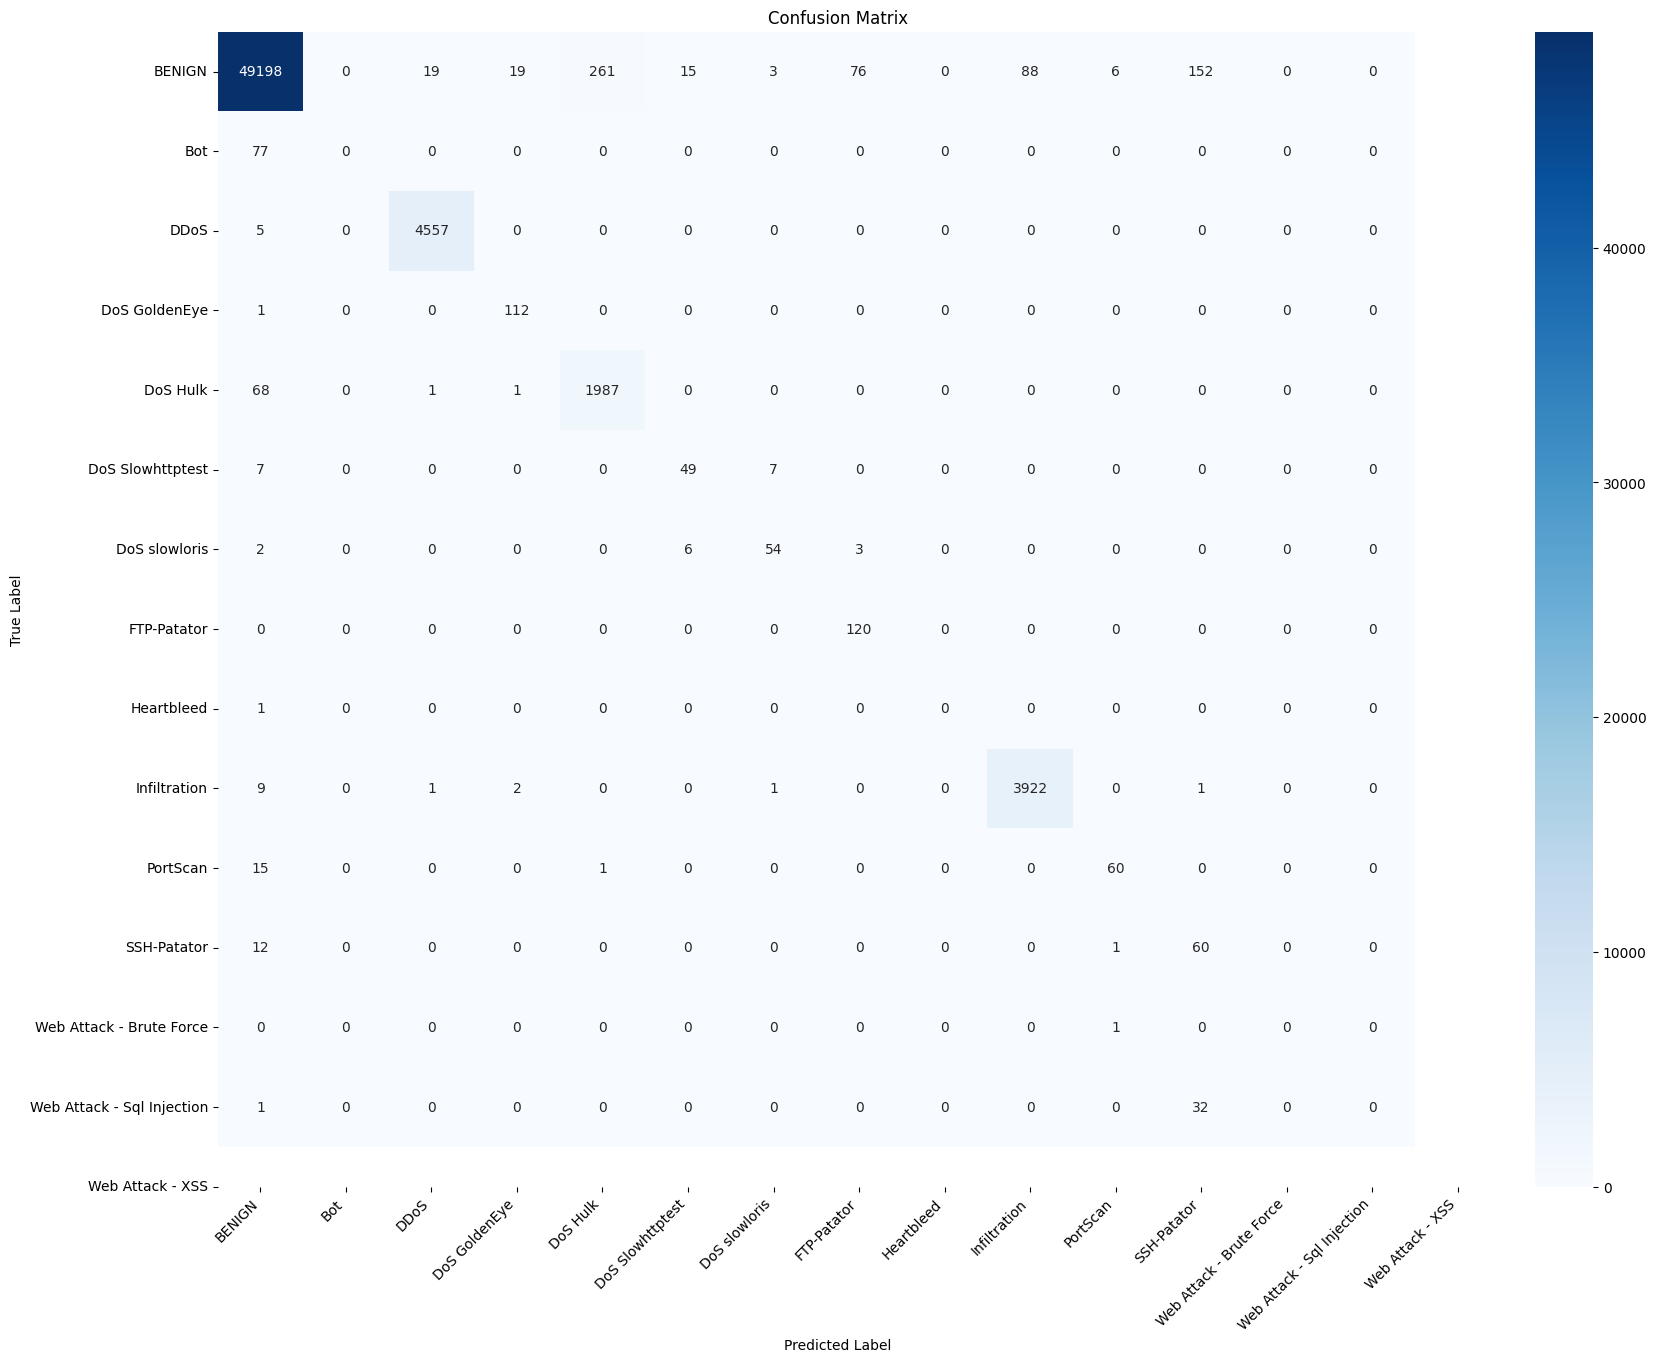

Weighted F1 Score: 0.9855705419776558
Cohen's Kappa Score: 0.9552248525984631


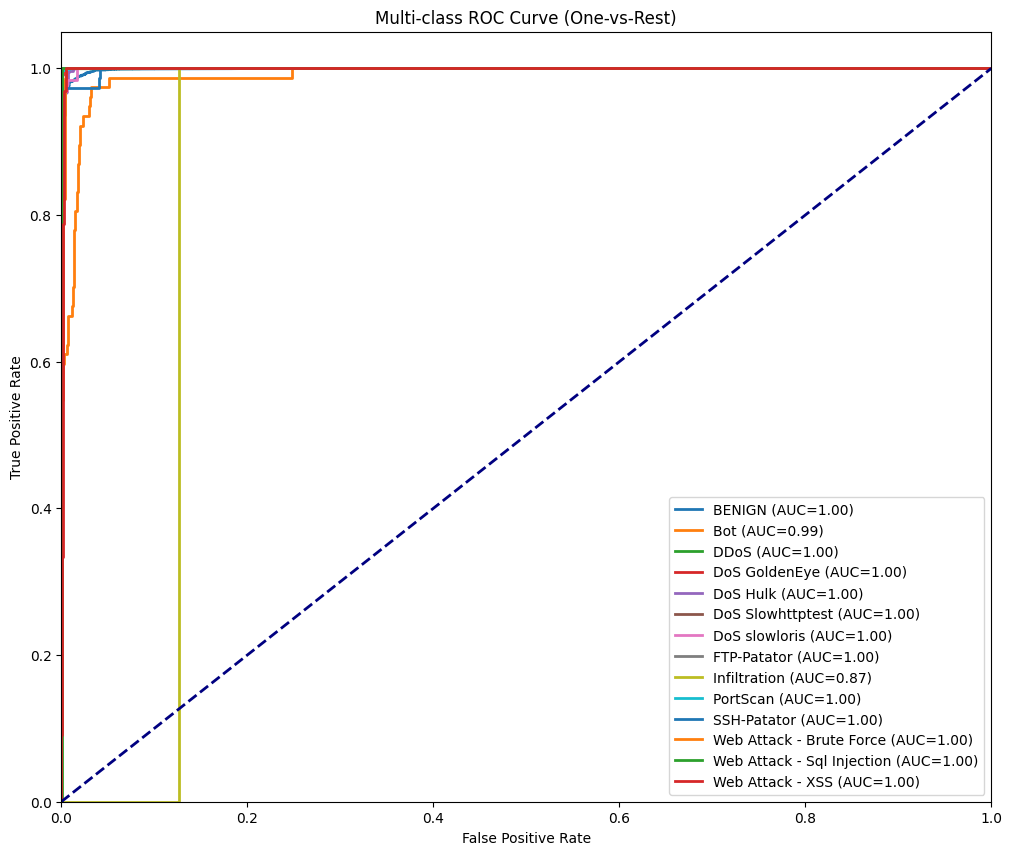

In [18]:
# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

# Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print("Macro F1 Score:", macro_f1)

# Overall Precision
overall_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Precision:", overall_precision)

# Overall Recall
overall_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
print("Overall Recall:", overall_recall)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
label_names = ohe.categories_[0]

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            annot_kws={"size": 10})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Weighted F1
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
print("Weighted F1 Score:", weighted_f1)

# Cohen's Kappa
kappa = cohen_kappa_score(y_true, y_pred)
print("Cohen's Kappa Score:", kappa)

# Multi-class ROC Curve
n_classes = y_test.shape[1]
plt.figure(figsize=(12, 10))
for i in range(n_classes):
    if y_test[:, i].sum() == 0 or np.all(y_pred_probs[:, i] == 0):
        continue
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label_names[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

# Save (DNN)

Save the model

In [ ]:
# Save model
model.save("cicids2017_model.keras")
print("Model saved as cicids2017_model.keras")

# Save test features
pd.DataFrame(X_test, columns=feature_names).to_csv("X_test.csv", index=False)
print("Test features saved as X_test.csv")

# Save test labels (convert from one-hot to integer)
y_labels = np.argmax(y_test, axis=1)
pd.DataFrame(y_labels, columns=['Label']).to_csv("y_test_labels.csv", index=False)
print("Test labels saved as y_test_labels.csv")

# Save feature names for reference
pd.DataFrame(feature_names, columns=['Feature']).to_csv("feature_names.csv", index=False)
print("Feature names saved as feature_names.csv")

Model saved as cicids2017_model.keras
Test features saved as X_test.csv
Test labels saved as y_test_labels.csv
Feature names saved as feature_names.csv


Verdict

In [19]:
print(f"Verdict: Achieved Accuracy = {accuracy:.4f}, Macro F1 = {macro_f1:.4f}. Overall performance is strong in terms of accuracy, but minority-class detection (precision/recall) could be improved.")


Verdict: Achieved Accuracy = 0.9853, Macro F1 = 0.5955. Overall performance is strong in terms of accuracy, but minority-class detection (precision/recall) could be improved.
